# Assignment 3 - Global Sensitivity Analysis

## Problem and Motivation

In the previous assignments we first derived a global optimum to our optimization problem consisting of estimating the best parameter vector to match the observed data. 
We then looked at the local sensity of the individual parameters. We now want to go a step further and look at the gloabl sensitivity. That is, we look how sensitive each parameter is when varying each simultaneously. This is beneficial compared to the local sensitivity analysis as first it detects and takes into account interdependencies. Especially, it can capture non-linear interactions, as again it quantifies how the uncertainty in the model output is partitioned among different parameters acting both individually and in combination. Furthermore, it enhances the fact that the conceptual model acts as a closed system where the different modules evolve depending on the parameter values and the different modules depend on the other. The global sensitivity analysis takes into account the whole parameter range and doesn't only look at the local gradients and small perturbations.

Hence, performing global sensitivity analysis is a great tool to evaluate model performance in the sense that it can detect really important and sensitive parameters as well as redundant parameters within our catchment. In fact, one can use it to perform model simplification and detect the parameters and hence the modules that mainly drive runoff in our catchment. In contrast to local sensitivity analysis, GSA is more robust as it evaluates the importance of parameters across their entire feasible range, it takes non-linear interdependencies into account and doesn't rely solely on small local perturbations. It is used as parameter uncertainty quantification.

# Theory and mathematical uncertainty quantification

The global sensitivity analysis we will use is based on the paper of Satelli et al: "Variance based sensitivity analysis of model output. Design and estimator
for the total sensitivity index" (2010), which basically describes Sobol-Sampling and the numerical computation of Sobol Indices to determine the sensitivity of the parameters. We will shortly discuss the procedure before showing the implementation and discussing the results. 

The paper (Sateli et al. 2010) discusses the Sobol indices as a variance based method using Monte Carlo. The core idea is to first understand our model as an equation $Y = f(X_1,X_2,...,X_d)$, where $Y$ is our OFV (the observed data) and $f$ is our objective function depending on our input parameters $X_i$. Using a special case of the Hoeffeding decomposition:
$$
f = f_0 + \sum_{i}f_i + \sum_{i}\sum_{j>i}f_{ij} + ... + f_{12..d}
$$
with
$$
f_0 = E[y],
$$
$$
𝑓_𝑖=𝐸_{𝑋_𝑖}(𝑌│𝑋_𝑖 )−𝐸(𝑌), 
$$
$$
𝑓_{𝑖𝑗}=𝐸_{𝑋_{𝑖𝑗}} (𝑌│𝑋_𝑖,𝑋_𝑗 )−𝑓_𝑖−𝑓_𝑗−𝐸(𝑌)
$$
and applying it to our OF, we arrive at two analytic indices.

First, the so called First-order (main effect) indice:
$$
S_i = \frac{Var_{X_i}(E_\bold{X~i}(Y|X_i))}{Var(Y)}
$$
which can be interpreted as the "expected reduction in variance that would be obtained if $X_i$ could be fixed". This correpsonds to the idea of the previous assignment, however, we look at the Variance and not the local gradients, making it more robust.

The second obtained indice is the so-called Total-Effect, which comines the main effect with all interactions:
$$
S_{T_i} = \frac{E_\bold{X~i}(Var_{X_i}(Y|\bold{X~i}))}{Var(Y)}
$$
which can be interpreted as the "expected variance that would be left if all factors but $X_i$ could be fixed".
This is pure global sensitivity analysis and a powerful result. For questions regarding the notation, please refer to the paper.

The main implementation problem now is to find a good numerical approximation for the two indices, which is provided by (Sateli et al. 2010).

First we need to generate samples from our parameters in order to compute the variance and means. For this we create two different sample matrices $A , B \in \bold{R}^{m \times p}$ where the inputs of the matrices are quasi-random numbers from our respective parameter densities, in our case uniform distribution across the whole provided range. Now, in order to compute the total and main effects, we need to be able to vary all parameters except one and vice versa. For this, we create a matrix $C \in \bold{R}^{m \times p}$ which is identical to the matrix $B$, except column $i$ is taken from matrix $A$. With our objective function being 1-NSE we define the vectors $y_A = f(A)$, $y_B = f(B)$ and $y_C = f(C)$. With this we can define the numerical approximators for our sobol indices:
$$
V = Var[f(A)]
$$
$$
S_{Ti} = E[(f(A) - f(C_i))^2] / (2 V)
$$
$$
S_i  = 1 - E[(f(B) - f(C_i))^2] / (2 V)
$$
As usual, we approximate the mean with the average as the underlying distribution is not known. Note that obviously from the definition it follows that $\sum_{i} S_{T_i} = 1$, which is a good check.

There are different approximations provided by Sateli et al., however the paper demonstrated that this one is the best from an accuracy and computational cost point of view.

# Implementation

After the theoretical explaination, one can compute it straight forward. This is the key code, we omit some defined functions. We hope that the name of the functions explains well enough what they do. Note that in the code we implemented two objective functions - the classical NSE and also the log NSE. Moreover, we present sensitivities over full range as well as we present sensitivities over ±20% of global optimum from assignment 1.

In [ ]:
def generate_sobol_AB(N, bounds):
    """
    Generate two independent Sobol matrices A and B in the given bounds
    using SciPy's Sobol sampler.

    We first generate an (N, 2d) matrix U in [0,1], then use each column pair
    (2i, 2i+1) to build independent coordinates for A[:, i] and B[:, i].
    
    """
    d = len(bounds)
    sampler = qmc.Sobol(d=2 * d, scramble=True)

    # U in [0,1]^(N × 2d)
    U = sampler.random(N)  # shape: (N, 2d)

    lower = np.array([lo for lo, hi in bounds], dtype=float)
    upper = np.array([hi for lo, hi in bounds], dtype=float)
    span = upper - lower

    A = np.empty((N, d), dtype=float)
    B = np.empty((N, d), dtype=float)

    for i in range(d):
        uA = U[:, 2 * i]
        uB = U[:, 2 * i + 1]

        A[:, i] = lower[i] + uA * span[i]
        B[:, i] = lower[i] + uB * span[i]

    return A, B


def sobol_indices_jansen_generic(f, bounds, N, label=""):
    """
    Compute first-order (S1) and total-effect (ST) Sobol indices
    using Jansen's radial design and SciPy Sobol sampling.

    Jansen estimators:
        V = Var[f(A)]
        S_Ti = E[(f(A) - f(C_i))^2] / (2 V)
        S_i  = 1 - E[(f(B) - f(C_i))^2] / (2 V)

    All expectations E[·] are approximated by np.mean over the N samples.
    """
    d = len(bounds)

    t0 = time.perf_counter()
    A, B = generate_sobol_AB(N, bounds)

    # Evaluate f on A and B
    fA = f(A)
    fB = f(B)

    V = np.var(fA, ddof=1)
    if V <= 0:
        raise RuntimeError("Variance of f(A) is zero or negative; Sobol indices undefined.")

    S1 = np.empty(d, dtype=float)
    ST = np.empty(d, dtype=float)
    evals = len(fA) + len(fB)

    # Radial design: for each i, build C_i by taking A and replacing column i with B[:, i]
    for i in range(d):
        C_i = A.copy()
        C_i[:, i] = B[:, i]

        fC_i = f(C_i)
        evals += len(fC_i)

        # np.mean implements E[·] over the Sobol points
        ST[i] = np.mean((fA - fC_i) ** 2.0) / (2.0 * V)
        S1[i] = 1.0 - np.mean((fB - fC_i) ** 2.0) / (2.0 * V)

    t1 = time.perf_counter()
    print(f"Sobol (Jansen) {label}: N={N}, d={d}, evals={evals}, time={t1 - t0:.3f} s")

    return S1, ST


# =========================================================
# 5. DUMMY TEST FUNCTION (VERIFY Σ S1 ≈ 1)
# =========================================================

def dummy_model(X):
    """
    Simple additive dummy model on [0,1]^3:
        f(x1, x2, x3) = x1 + 2 x2^2 + sin(pi x3)
    It's additive → no interactions → sum of first-order Sobol indices ≈ 1.
    """
    x1 = X[:, 0]
    x2 = X[:, 1]
    x3 = X[:, 2]
    return x1 + 2.0 * x2**2 + np.sin(np.pi * x3)


def run_dummy_test():
    print("\n=== Dummy test: additive function on [0,1]^3 ===")

    d_bounds = [[0.0, 1.0]] * 3
    N_test = 4096

    S1_dummy, ST_dummy = sobol_indices_jansen_generic(
        dummy_model,
        d_bounds,
        N_test,
        label="Dummy f"
    )

    print("Dummy S1:", S1_dummy)
    print("Dummy ST:", ST_dummy)
    print("Sum of S1 (should be close to 1):", np.sum(S1_dummy))


# =========================================================
# 6. PLOTTING
# =========================================================
#...
# =========================================================
# 7. MAIN WORKFLOW
# =========================================================

def main():
    # --- Load data and setup HBV ---
    df = load_hbv_inputs()
    setup_hbv_model()

    # --- Run dummy verification test ---
    run_dummy_test()
    # is the sum of S1 close to 1 for the dummy model? This verifies our Sobol implementation is correct.

    # Define HBV objective wrappers
    def f_HBV_NSE(X):
        return evaluate_hbv_matrix(X, objective="NSE")

    def f_HBV_LN(X):
        return evaluate_hbv_matrix(X, objective="LnNSE")

    N = 10000  # base sample size for HBV Sobol

    # === 1) FULL RANGE – NSE ===
    S1_full_NSE, ST_full_NSE = sobol_indices_jansen_generic(
        f_HBV_NSE,
        full_range_bounds,
        N,
        label="HBV full range, NSE"
    )
    print_sobol_table(S1_full_NSE, ST_full_NSE, param_names, "FULL RANGE – NSE")
    plot_sobol(S1_full_NSE, ST_full_NSE, "FULL RANGE – NSE", param_names)
    sum_S1_full_NSE = np.sum(S1_full_NSE)
    print(f"Sum of S1 (FULL RANGE – NSE): {sum_S1_full_NSE:.3f}")
    # === 2) FULL RANGE – LnNSE ===
    S1_full_LN, ST_full_LN = sobol_indices_jansen_generic(
        f_HBV_LN,
        full_range_bounds,
        N,
        label="HBV full range, LnNSE"
    )
    print_sobol_table(S1_full_LN, ST_full_LN, param_names, "FULL RANGE – LnNSE")
    plot_sobol(S1_full_LN, ST_full_LN, "FULL RANGE – LnNSE", param_names)
    sum_S1_full_LN = np.sum(S1_full_LN)
    print(f"Sum of S1 (FULL RANGE – LnNSE): {sum_S1_full_LN:.3f}")
    # === 3) NARROW RANGE – NSE ===
    S1_narrow_NSE, ST_narrow_NSE = sobol_indices_jansen_generic(
        f_HBV_NSE,
        narrow_bounds,
        N,
        label="HBV narrow range, NSE"
    )
    print_sobol_table(S1_narrow_NSE, ST_narrow_NSE, param_names, "NARROW RANGE – NSE")
    plot_sobol(S1_narrow_NSE, ST_narrow_NSE, "NARROW RANGE – NSE", param_names)
    sum_S1_narrow_NSE = np.sum(S1_narrow_NSE)
    print(f"Sum of S1 (NARROW RANGE – NSE): {sum_S1_narrow_NSE:.3f}")

    # === 4) NARROW RANGE – LnNSE ===
    S1_narrow_LN, ST_narrow_LN = sobol_indices_jansen_generic(
        f_HBV_LN,
        narrow_bounds,
        N,
        label="HBV narrow range, LnNSE"
    )
    print_sobol_table(S1_narrow_LN, ST_narrow_LN, param_names, "NARROW RANGE – LnNSE")
    plot_sobol(S1_narrow_LN, ST_narrow_LN, "NARROW RANGE – LnNSE", param_names)
    sum_S1_narrow_LN = np.sum(S1_narrow_LN)
    print(f"Sum of S1 (NARROW RANGE – LnNSE): {sum_S1_narrow_LN:.3f}")
    # === Build DataFrame with all results ===
        # =====================================================
    # 5) BUILD AND SAVE SOBOL TABLE
    # =====================================================

    df_sobol = build_sobol_dataframe(
        param_names,
        S1_full_NSE, ST_full_NSE,
        S1_full_LN,  ST_full_LN,
        S1_narrow_NSE, ST_narrow_NSE,
        S1_narrow_LN,  ST_narrow_LN
    )

    # Round for readability
    df_sobol_round = df_sobol.copy()
    for col in df_sobol.columns[1:]:
        df_sobol_round[col] = df_sobol[col].round(4)

    # Print to console
    print("\n=== Sobol sensitivity indices summary ===")
    print(df_sobol_round.to_string(index=False))

    # Save to CSV (recommended for report)
    out_csv = DATA_DIR / "sobol_indices_HBV_full_vs_narrow.csv"
    df_sobol_round.to_csv(out_csv, index=False)

# Results

There are a few aspects we can discuss. First we can compare the effect of the objective function. Second, we can compare the main effect with the total effect. Then, we can compare the effect of the range considered and finally we can look at the big picture which parameters seem to be the most sensitive globally speaking.

First, let's compare the effect of the traditional NSE vs the log NSE. Looking at the formula of the latter we see that:
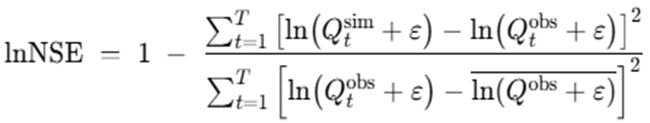

Hence, small simulated discharges are enhanced in log and large flows less influence the outcome as the identity is greater than the log.
Furthermore, if an observation and respective simulation differ a lot, the log amplifies the difference. Hence, using another objective function clearly influences the Sobol indices outcome. Hence, logNSE puts more weight on low flows.

This can also be observed visually:
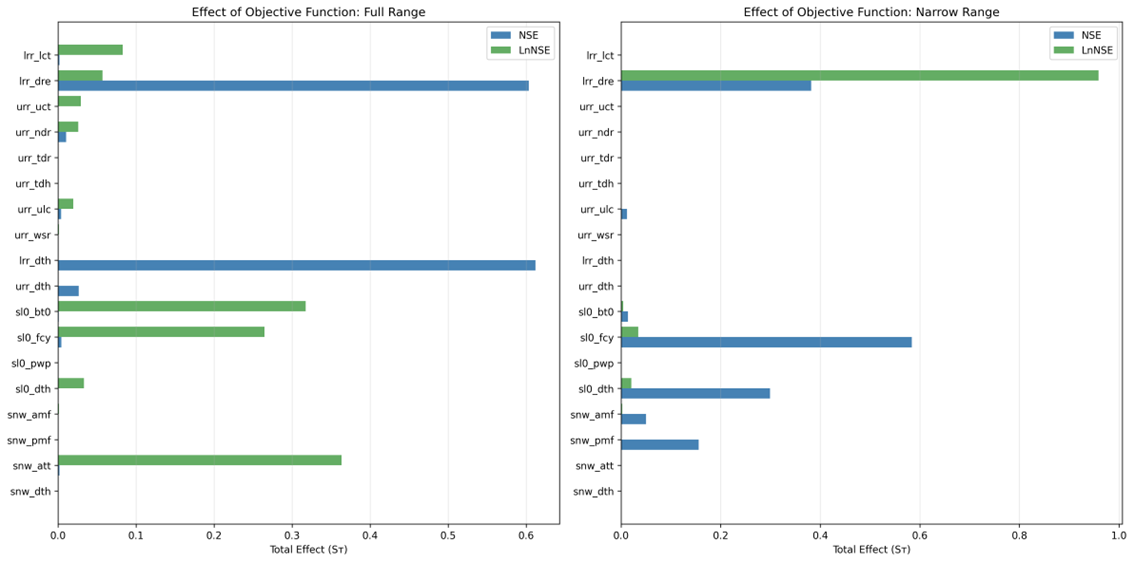

This plots show the total effect of the different parameter over the full range on the left and over the narrow range on the right. In each plot, it distinguishes between the two objective function. In green we see the log NSE and in blue we see the classical NSE.

We observe that lnNSE distributes the Sobol indices more among all parameters. It is less peaky as expected. It is interesting that under the log NSE the parameter "threshold temperature (snw_att)" has a larger total effect. This is because in NSE, this parameter's effect is masked by high flow variability. But in log NSE, where low flows carry more weight, the snow temperature threshold becomes more sensitive because it directly controls the timing and magnitude of low flows during snow-dominated periods. However, one should keep in mind that if we look at snw_att over the full range, we get physical inconsistent results as for instance snow doesn't melt at negative air temperatures.

As discussed in the presentations, logNSE "democratizes" the sensitivity analysis by giving all flow conditions (not just peaks) a voice. This reveals sensitivities that NSE ignores and distributes importance across parameters affecting different modules. Another example is the soil depth, which becomes critical for matching peaks with NSE but remains unimportant for matching low flows with LnNSE.

In this plot we also see that the width of the considered range matters. Let's take a closer look at it:
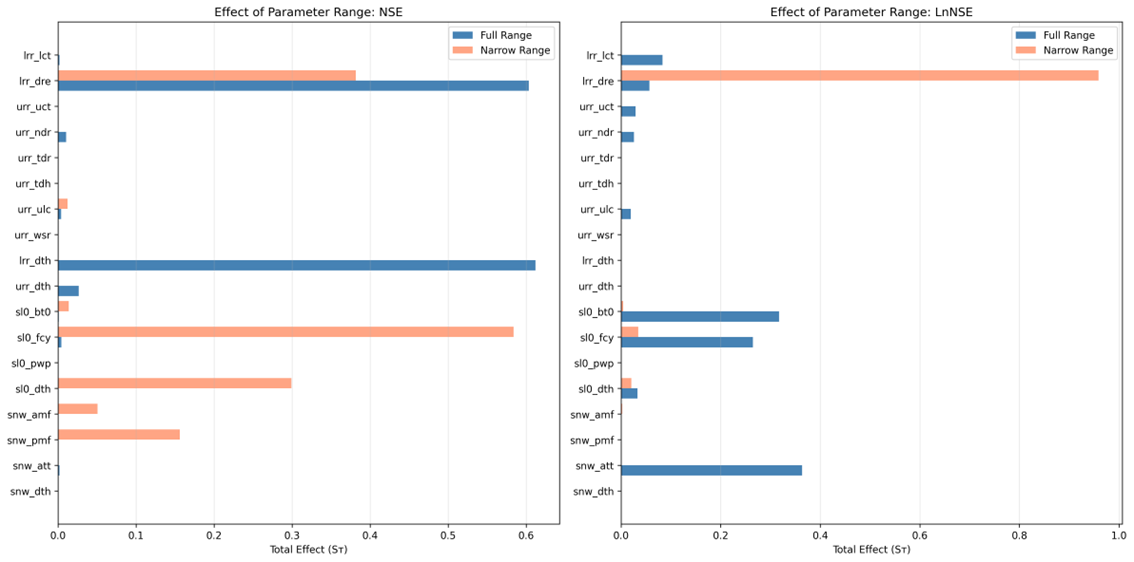

We plotted the total effects of the individual parameters with the NSE as OF on the left and with the lnNSE on the right. In each subplot we plotted the total effect over the full range in blue and over the narrow range in red. We see that in both cases the results highly depend on the considered range. To analysze further let's look at the sum of the total effects:

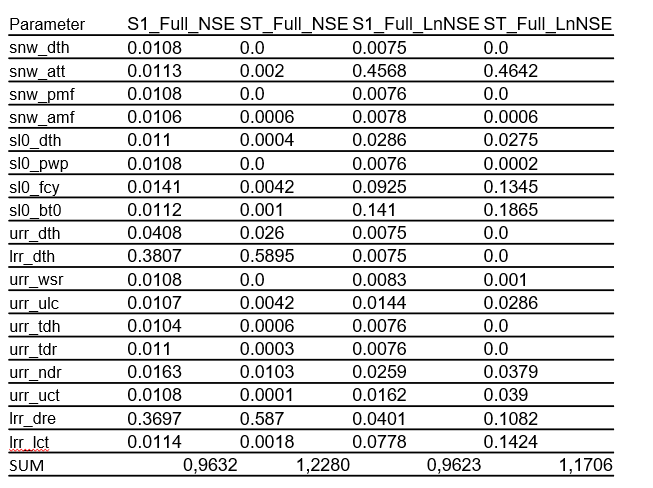

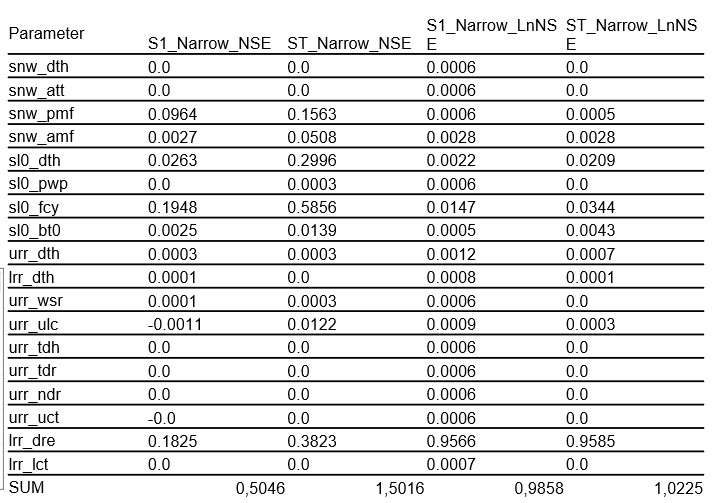

We see that over the narrow range, $\sum_{i} S_{T_i} = 1$ doesn't hold. That is expected as considering a narrow range contradicts the core idea of Sobol indices where we explicitly wnat to consider the full range in order to detect interactions. We also got negative values which is due to numerical instability in the narrow case and something that we cleary do not want. So, it is more useful to perform GSA over the full range or at least over a wider narrow range. Moreover, in the narrow range we assumed that we found a global minimum which is quiet a strong assumption that is not granted.

Let's quickly review the effect of main effect and total effect over the full range without loss of generality.
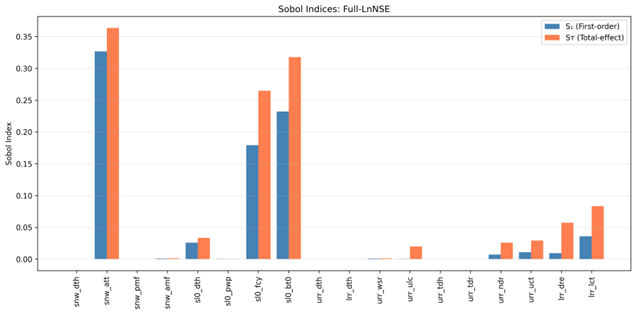

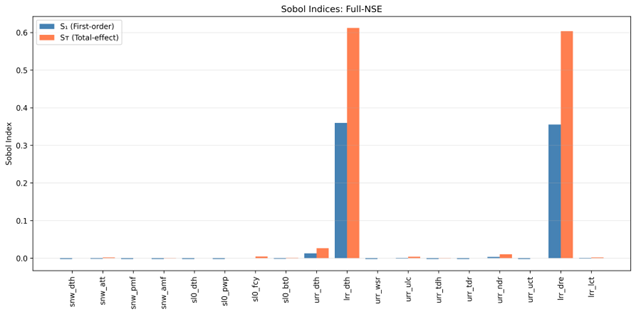

In both cases we see that the total effect dominates the main effect. This is quite intuitive: If the main effect itself is not negligible, the total effect will be larger as it  also considers the interactions of the parameters. As seen above, the sum of it are close to one. Personally, we would say that for sensitivity analysis the total effects are more insightful as it considers interactions. In our case, we could for instance tell that the upper resevoir parameters are not really sensitive and could think of omitting it. Our catchment is mainly driven by lower flows and the snow module. Again, keep in mind that NSE and logNSE emphasize different aspects of our model.

# Connections to previous assignments

With this analysis, we completed parameter uncertainity quantification.  It is insightful to compare the results with the local sensitivity analysis. Here are a few examples:

1. SNow module - Threshold temperature

Looking at the band plot we saw in assignment 1 that snw_att is locally sensitive. It is also globally sensitive if we look at the full range logNSE result. This is again because if we consider the full range, we get physical inconsistent results as snow doesnt melt at negative temperatures. This is a perfect example that one needs to make physical sense of the results.
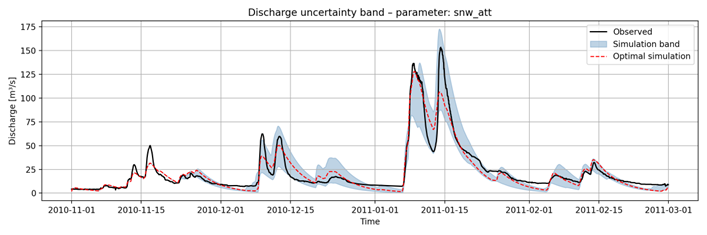

2. Upper reservoir parameters

In both the local and global sensitivty analysis we saw that those parameters are not sensitive. Hence, we could conclude that the high flows are less sensitive compared to low flows. This also makes physical sense as the internal variable of the upper reservoir flows never reach the assigned thrshold that activates the module.
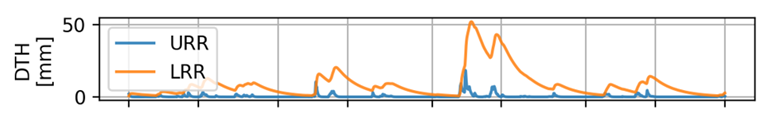

3. Soil module - Soil field capacity

This parameter matters according to the GSA. Locally, we observed the parabloic shape indicating local sensitivity, however the y-axis scale tells us that around our optimum the changes are marginal.
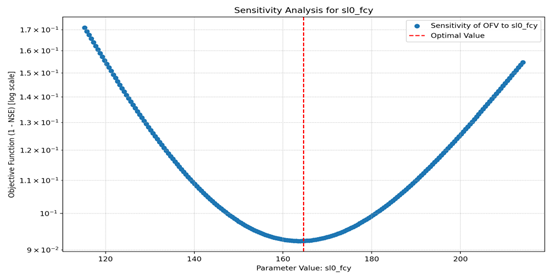

The band plot shows us that parameter uncertainty mainly occurs in the beginning of the observation period. Hence, we conclude that slo_fcy is particularly important for initial model conditions and early discharge predictions. It drives the "spin-off phase".

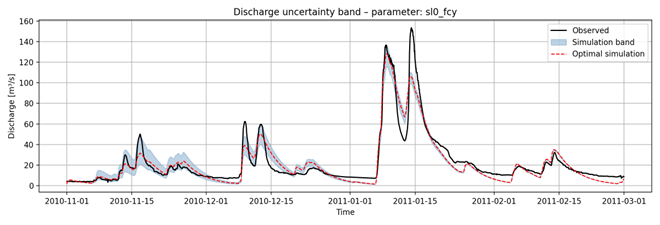

4. Lower reservoir parameters

We saw that in both ranges and with both objective functions that these parameters are globally sensitive and interact a lot as the total effects are a lot higher than the main effects. This confirms our local sensitivity analysis, for instance when looking at the scatter plot of the OFV of lrr_dre:
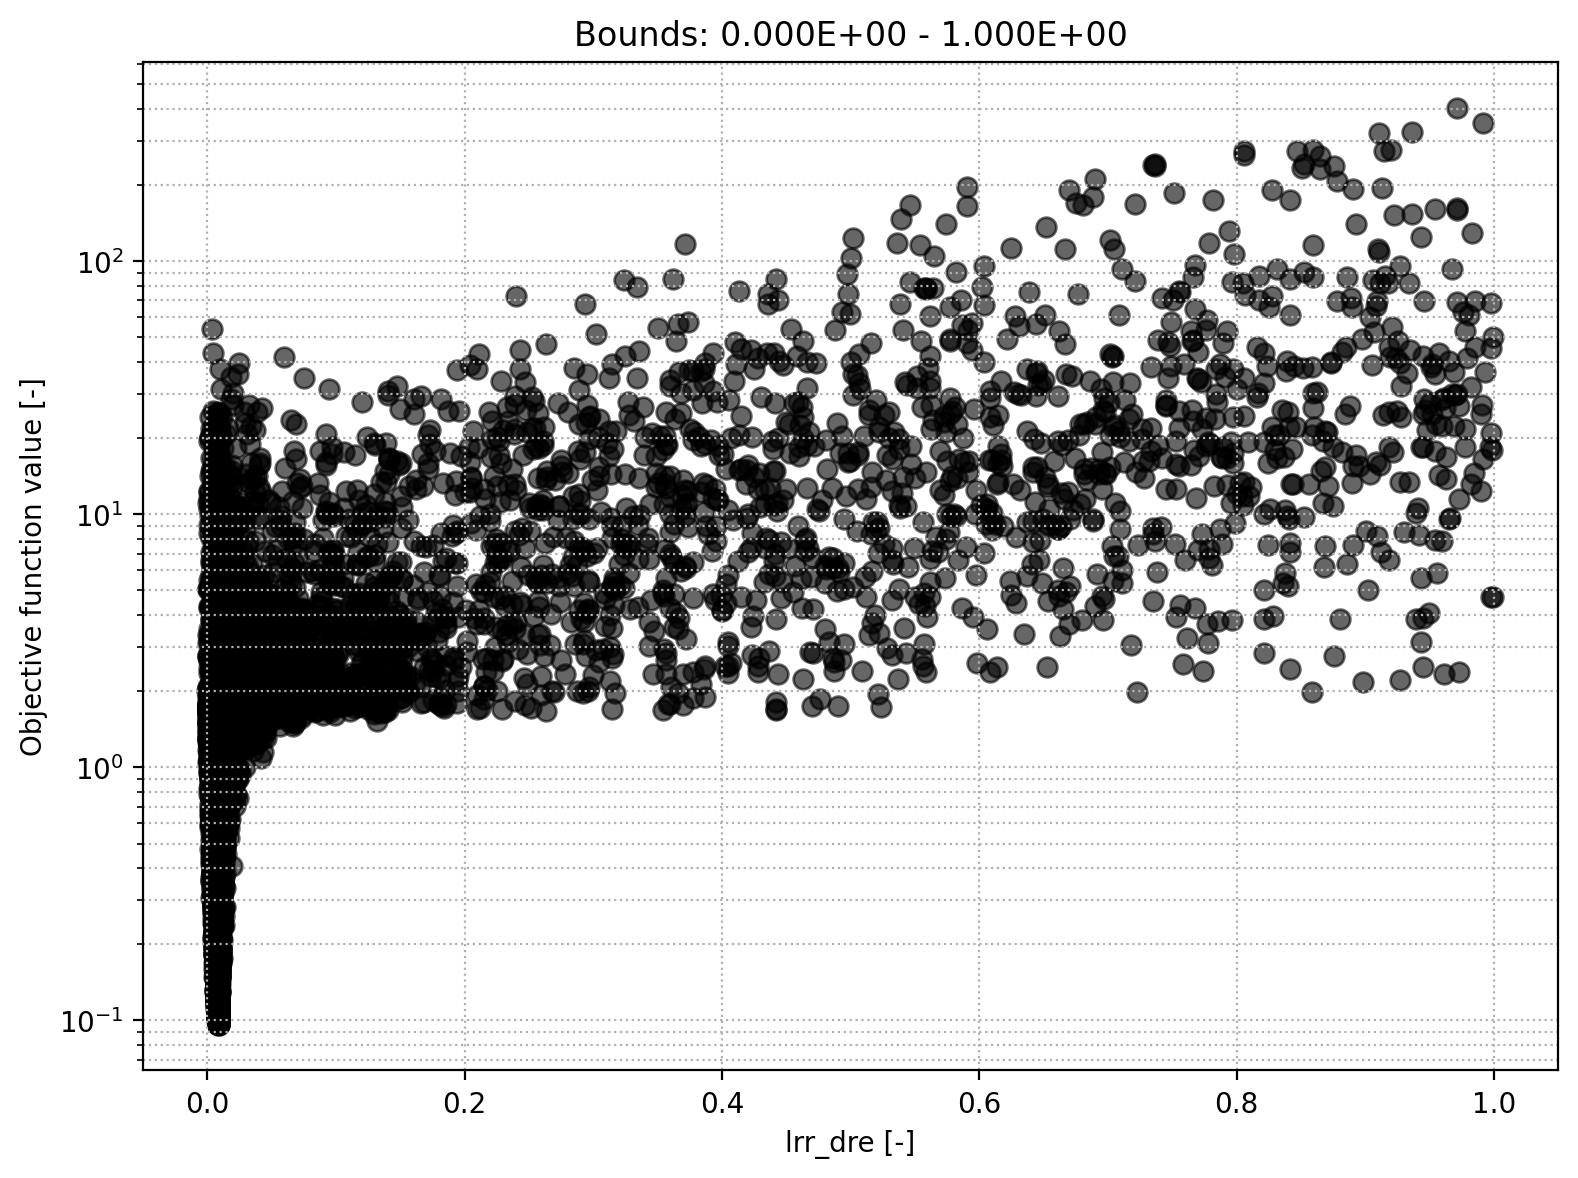

This concludes assignment 3 report.